In [1]:
import pandas as pd
from pymatgen.core import Structure
from mp_api.client import MPRester
import os

c:\venvs\battery_gnn\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
csv_file = r"datos_baterias_mp\baterias_clean.csv"
df = pd.read_csv(csv_file)
df_clean = df.copy()

print(df_clean.shape)
display(df_clean.head())

(6847, 15)


,battery_formula,working_ion,average_voltage,capacity_grav,capacity_vol,energy_grav,energy_vol,max_delta_volume,max_voltage_step,stability_charge,stability_discharge,framework_formula,num_steps,last_updated,energy_estimada
0,Cs0-3Ac,Cs,-0.707763,128.499827,404.648831,-90.947418,-286.395455,6.270133,0.0,0.020409,0.535925,Ac,1,2025-09-19 09:41:17.571210+00:00,-90.947418
1,Ca0-3Ac,Ca,-0.034773,463.113885,1586.172049,-16.103762,-55.155628,2.709372,0.0,0.020409,0.057262,Ac,1,2025-09-19 09:42:20.982522+00:00,-16.103762
2,Li0-1CsAcO3,Li,2.147050,64.606066,371.641866,138.712466,797.933730,0.036626,0.0,0.219559,0.300647,CsAcO3,1,2025-09-19 09:43:22.301779+00:00,138.712466
3,Na0-3Ag,Na,-0.008959,454.679804,1215.877630,-4.073349,-10.892707,5.098846,0.0,0.003609,0.045182,Ag,1,2025-09-19 09:42:57.716505+00:00,-4.073349
4,Li0-3Ag,Li,0.210565,624.785871,1984.816229,131.558310,417.933696,2.736089,0.0,0.003609,0.000000,Ag,1,2025-09-19 09:43:24.372752+00:00,131.558310


In [3]:
API_KEY = os.environ["MP_API_KEY"]

with MPRester(API_KEY) as mpr:

    docs = mpr.materials.insertion_electrodes.search(
        fields=[
            "battery_formula",
            "working_ion",
            "framework_formula",
            "max_delta_volume",
            "material_ids",
            "host_structure",
            "average_voltage",
            "capacity_grav",
            "capacity_vol",
            "stability_charge",
            "stability_discharge",
        ]
    )



print(len(docs))

mp_api.client.core.client - WARNING - Dataset for insertion-electrodes already exists at C:\Users\NereaBorjaGonzález\mp_datasets\build\collections\insertion-electrodes, returning existing dataset.
mp_api.client.core.client - INFO - Delete or move existing dataset or re-run search query with MPRester(force_renew=True) to refresh local dataset.


6847


In [4]:
data = []

for i in range(len(docs)):
    doc = docs[i]

    if doc.host_structure is not None:
        data.append({
            "index": i,
            "battery_formula": doc.battery_formula,
            "working_ion": doc.working_ion,
            "framework_formula": doc.framework_formula,
            "max_delta_volume": doc.max_delta_volume,
            "average_voltage": doc.average_voltage,
            "capacity_grav": doc.capacity_grav,
            "capacity_vol": doc.capacity_vol,
            "stability_charge": doc.stability_charge,
            "stability_discharge": doc.stability_discharge,
            "n_atoms": len(doc.host_structure),
            "volume": doc.host_structure.volume,
            "structure": doc.host_structure,
        })

mp_df = pd.DataFrame(data)

print("Muestras con estructura:", len(mp_df))

C:\Users\NereaBorjaGonzález\AppData\Local\Temp\ipykernel_47456\2105470833.py:4: MPDatasetIndexingWarning: 
            Pythonic indexing into arrow-based MPDatasets is sub-optimal, consider using
            idiomatic arrow patterns. See MP's docs on MPDatasets for relevant examples:
            docs.materialsproject.org/materials-project-data-lakehouse/arrow-datasets
            
  doc = docs[i]


Muestras con estructura: 6847


In [5]:
mp_df_unique = mp_df.drop_duplicates(
    subset=[
        "battery_formula",
        "framework_formula",
        "max_delta_volume"
    ]
).copy()

print("mp_df original:", len(mp_df))
print("mp_df único:", len(mp_df_unique))

mp_df original: 6847
mp_df único: 6838


In [6]:
matches = df_clean.merge(
    mp_df_unique,
    on=[
        "battery_formula",
        "framework_formula",
        "max_delta_volume"
    ],
    how="left",
    suffixes=("_dataset", "_mp")
)

print("Filas:", len(matches))
print(
    "Con estructura:",
    matches["structure"].notna().sum()
)
print(
    "Porcentaje con estructura:",
    round(
        100 * matches["structure"].notna().mean(),
        2
    ),
    "%"
)

Filas: 6847
Con estructura: 3476
Porcentaje con estructura: 50.77 %


In [7]:
assert len(matches) == len(df_clean)

print("✓ El merge no ha aumentado el número de filas")
print("✓ Filas:", len(matches))

✓ El merge no ha aumentado el número de filas
✓ Filas: 6847


In [8]:
assert matches["structure"].notna().sum() == 3476

print("✓ Estructuras encontradas:", matches["structure"].notna().sum())
print("✓ Cobertura:", round(100 * matches["structure"].notna().mean(), 2), "%")

✓ Estructuras encontradas: 3476
✓ Cobertura: 50.77 %


In [9]:
gnn_df = matches[
    matches["structure"].notna()
].copy()

print("Muestras para GNN:", len(gnn_df))

Muestras para GNN: 3476


In [10]:
print("Tipo de estructura:")
print(type(gnn_df.iloc[0]["structure"]))

print("\nPrimera estructura:")
structure = gnn_df.iloc[0]["structure"]

print("Fórmula:", structure.formula)
print("Átomos:", len(structure))
print("Volumen:", structure.volume)

Tipo de estructura:
<class 'pymatgen.core.structure.Structure'>

Primera estructura:
Fórmula: Ac1
Átomos: 1
Volumen: 45.38459984315082


In [11]:
print("Muestras:", len(gnn_df))

print(
    "Estructuras nulas:",
    gnn_df["structure"].isna().sum()
)

print(
    "Átomos mínimo:",
    gnn_df["n_atoms"].min()
)

print(
    "Átomos máximo:",
    gnn_df["n_atoms"].max()
)

print(
    "Volumen mínimo:",
    gnn_df["volume"].min()
)

print(
    "Volumen máximo:",
    gnn_df["volume"].max()
)

Muestras: 3476
Estructuras nulas: 0
Átomos mínimo: 1.0
Átomos máximo: 144.0
Volumen mínimo: 5.602384346861016
Volumen máximo: 2308.277205844844


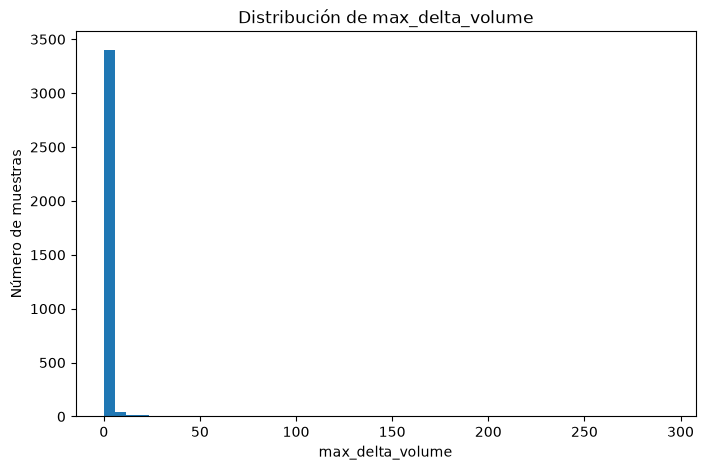

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    gnn_df["max_delta_volume"],
    bins=50
)

plt.xlabel("max_delta_volume")
plt.ylabel("Número de muestras")
plt.title("Distribución de max_delta_volume")

plt.show()

In [13]:
print("NaN en target:",
      gnn_df["max_delta_volume"].isna().sum())

print("\nTarget:")
print(gnn_df["max_delta_volume"].describe())

NaN en target: 0

Target:
count    3476.000000
mean        0.662275
std         7.903805
min         0.000016
25%         0.022889
50%         0.056980
75%         0.119762
max       293.193218
Name: max_delta_volume, dtype: float64


In [14]:
print("Estructuras con más átomos:")
print(
    gnn_df[
        [
            "battery_formula",
            "framework_formula",
            "n_atoms",
            "volume",
            "max_delta_volume"
        ]
    ]
    .sort_values("n_atoms", ascending=False)
    .head(10)
)

Estructuras con más átomos:
         battery_formula framework_formula  n_atoms       volume  \
4384          Na0-1CoPO4             CoPO4    144.0  2308.277206   
5905       Li0-1Mo(PO4)2          Mo(PO4)2    132.0  1919.043444   
2780     Li0-1Mn4(P2O7)3        Mn4(P2O7)3    124.0  1581.393897   
838             K0-0.02C                 C    120.0  1372.919865   
2276    Li0-4MnH6(S2O9)2       MnH6(S2O9)2    116.0  1573.144418   
6170     Na0-1ZrNb(PO4)3        ZrNb(PO4)3    102.0  1564.434781   
3483        Mg0-0.07V2O5              V2O5     98.0  1503.977237   
5492  Li0-1Na2Fe(Si2O5)3     Na2Fe(Si2O5)3     96.0  1282.058214   
2750          Li0-1MnPO4             MnPO4     96.0  1540.847112   
2696          Li0-1MnPO4             MnPO4     96.0  1536.630673   

      max_delta_volume  
4384          0.050195  
5905          0.016243  
2780          0.033980  
838           0.032825  
2276          0.034772  
6170          0.001077  
3483          0.010629  
5492          0.000401 

In [15]:
print("Estructuras con mayor volumen:")
print(
    gnn_df[
        [
            "battery_formula",
            "framework_formula",
            "n_atoms",
            "volume",
            "max_delta_volume"
        ]
    ]
    .sort_values("volume", ascending=False)
    .head(10)
)

Estructuras con mayor volumen:
       battery_formula framework_formula  n_atoms       volume  \
4384        Na0-1CoPO4             CoPO4    144.0  2308.277206   
1466     K0-3Cr2(PS4)3         Cr2(PS4)3     68.0  1985.220981   
5905     Li0-1Mo(PO4)2          Mo(PO4)2    132.0  1919.043444   
3729      Li4.25-4.4Sn                Sn     20.0  1900.773177   
3742         K0-0.17Sn                Sn     46.0  1890.621051   
3737        Cs0-0.17Sn                Sn     46.0  1890.621051   
6076      K0-2Mo15Se19          Mo15Se19     68.0  1607.453987   
950       Cs0-1Zr6CI14           Zr6CI14     42.0  1593.608922   
2780   Li0-1Mn4(P2O7)3        Mn4(P2O7)3    124.0  1581.393897   
2276  Li0-4MnH6(S2O9)2       MnH6(S2O9)2    116.0  1573.144418   

      max_delta_volume  
4384          0.050195  
1466          0.134567  
5905          0.016243  
3729          0.009450  
3742          0.071733  
3737          0.091710  
6076          0.032919  
950           0.008821  
2780          0.0

Guardado de datos

In [16]:
gnn_df.to_pickle("datos_baterias_mp/gnn_dataset.pkl")

Comprobaciones realizadas para poder hacer el merge adecuadamente

In [17]:
print("df_clean:", len(df_clean))
print("mp_df:", len(mp_df))

df_clean: 6847
mp_df: 6847


In [18]:
print("df_clean:")
print(df_clean.columns.tolist())

print("\nmp_df:")
print(mp_df.columns.tolist())

df_clean:
['battery_formula', 'working_ion', 'average_voltage', 'capacity_grav', 'capacity_vol', 'energy_grav', 'energy_vol', 'max_delta_volume', 'max_voltage_step', 'stability_charge', 'stability_discharge', 'framework_formula', 'num_steps', 'last_updated', 'energy_estimada']

mp_df:
['index', 'battery_formula', 'working_ion', 'framework_formula', 'max_delta_volume', 'average_voltage', 'capacity_grav', 'capacity_vol', 'stability_charge', 'stability_discharge', 'n_atoms', 'volume', 'structure']


In [19]:
for key in [
    "battery_formula",
    "framework_formula"
]:
    a = set(df_clean[key].dropna())
    b = set(mp_df[key].dropna())

    print(
        key,
        "→ comunes:", len(a & b),
        "| df_clean:", len(a),
        "| mp_df:", len(b)
    )

battery_formula → comunes: 5397 | df_clean: 5397 | mp_df: 5397
framework_formula → comunes: 3161 | df_clean: 3161 | mp_df: 3161


In [20]:
print(
    "Coincidencias de max_delta_volume:",
    len(
        set(df_clean["max_delta_volume"].dropna())
        &
        set(mp_df["max_delta_volume"].dropna())
    )
)

Coincidencias de max_delta_volume: 3470


In [21]:
matches_test = df_clean.merge(
    mp_df,
    on=[
        "battery_formula",
        "framework_formula",
        "working_ion"
    ],
    how="left",
    suffixes=("_dataset", "_mp")
)

print("Shape:", matches_test.shape)

print(
    "Con estructura:",
    matches_test["structure"].notna().sum()
)

print(
    "Porcentaje:",
    round(
        100 * matches_test["structure"].notna().mean(),
        2
    ),
    "%"
)

Shape: (6847, 25)
Con estructura: 0
Porcentaje: 0.0 %


In [22]:
test_merge = df_clean.merge(
    mp_df,
    on=[
        "battery_formula",
        "framework_formula"
    ],
    how="left"
)

print("Filas:", len(test_merge))
print(
    "Con estructura:",
    test_merge["structure"].notna().sum()
)

Filas: 15205
Con estructura: 15205


In [23]:
duplicados = (
    mp_df.groupby(
        [
            "battery_formula",
            "framework_formula",
            "max_delta_volume"
        ]
    )
    .size()
    .reset_index(name="count")
)

print(
    duplicados[
        duplicados["count"] > 1
    ]
)

       battery_formula framework_formula  max_delta_volume  count
1506    Li0-1La8Cu3O16         La8Cu3O16          0.005890      2
1591       Li0-1MnPHO5            MnPHO5          0.095658      2
1818       Li0-1SnPHO5            SnPHO5          0.158758      2
1958       Li0-1V4O5F7            V4O5F7          0.012103      2
2000  Li0-1VCrP2(O4F)2       VCrP2(O4F)2          0.017284      2
2022  Li0-1VFeP2(O4F)2       VFeP2(O4F)2          0.017783      2
2472      Li0-3Mn5OF11           Mn5OF11          0.041464      2
2766     Li0-4V4(OF3)3          V4(OF3)3          0.025998      2
3287  Li1-3VCrP2(HO5)2       VCrP2(HO5)2          0.076598      2


In [24]:
duplicadas = mp_df.merge(
    duplicados[
        duplicados["count"] > 1
    ][
        [
            "battery_formula",
            "framework_formula",
            "max_delta_volume"
        ]
    ],
    on=[
        "battery_formula",
        "framework_formula",
        "max_delta_volume"
    ],
    how="inner"
)

print(
    duplicadas[
        [
            "battery_formula",
            "framework_formula",
            "max_delta_volume",
            "n_atoms",
            "volume"
        ]
    ]
)

     battery_formula framework_formula  max_delta_volume  n_atoms      volume
0     Li0-1La8Cu3O16         La8Cu3O16          0.005890       27  374.068318
1     Li0-1La8Cu3O16         La8Cu3O16          0.005890       27  374.068318
2        Li0-1MnPHO5            MnPHO5          0.095658       16  166.622012
3        Li0-1MnPHO5            MnPHO5          0.095658       16  166.622012
4        Li0-1SnPHO5            SnPHO5          0.158758       16  189.530258
5        Li0-1SnPHO5            SnPHO5          0.158758       16  189.530258
6   Li0-1VCrP2(O4F)2       VCrP2(O4F)2          0.017284       14  173.805633
7   Li0-1VCrP2(O4F)2       VCrP2(O4F)2          0.017284       14  173.805633
8   Li1-3VCrP2(HO5)2       VCrP2(HO5)2          0.076598       16  178.061298
9   Li1-3VCrP2(HO5)2       VCrP2(HO5)2          0.076598       16  178.061298
10  Li0-1VFeP2(O4F)2       VFeP2(O4F)2          0.017783       14  176.213764
11  Li0-1VFeP2(O4F)2       VFeP2(O4F)2          0.017783       1

In [25]:
mp_df_unique = mp_df.drop_duplicates(
    subset=[
        "battery_formula",
        "framework_formula",
        "max_delta_volume"
    ]
).copy()

print("mp_df:", len(mp_df))
print("mp_df_unique:", len(mp_df_unique))

mp_df: 6847
mp_df_unique: 6838
